In [1]:
# Imports
import numpy as np
import pandas as pd
from scipy.linalg import lstsq
from sympy import *
import matplotlib.pyplot as plt
init_printing(use_latex=true)
filename = "DataUse.xlsx"

# Input real data


In [2]:
# Establish number of wells
n = pd.read_excel(filename, sheet_name='n').iloc[0,0]
n

4

In [3]:
# Establish number of timepoints
T = pd.read_excel(filename, sheet_name='T').iloc[0,0]
T

1461

In [4]:
zReal = pd.read_excel(filename, sheet_name="OnOff").to_numpy().T   # Only binary at this point
zReal[pd.isna(zReal)] = 0
sum(zReal.T)

array([1345., 1230., 1222.,    0.])

In [5]:
tftReal = pd.read_excel(filename, sheet_name="TFTs").to_numpy().T   # Non-binary, contains TFT measurement.
tftReal[pd.isna(tftReal)] = 0
numTfts = np.count_nonzero(tftReal)
tftReal

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [6]:
dReal = np.zeros(tftReal.shape)
for r in range(len(dReal)):
    for c in range(len(dReal[0])):
        if tftReal[r,c] != 0:
            dReal[r,c] = 1
dReal

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [7]:
# Establish vector of expert-estimated mass flows
mEstimates = pd.read_excel(filename, sheet_name="MassFlowEstimates").to_numpy().T
mEstimates[pd.isna(mEstimates)] = 0
mEstimates

array([[29.16447097, 29.41802201, 29.44433852, ..., 37.38156896,
        36.96219626, 37.58281756],
       [60.69242432, 60.9400594 , 60.88349717, ..., 76.10930743,
        75.69367963, 75.39730625],
       [39.68307507, 39.84239784, 39.85947378, ..., 62.22377388,
        61.76020397, 62.16625229],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]])

In [8]:
# Establish vector of total mass flow at the separator over time
MReal = pd.read_excel(filename, sheet_name="TotalMassFlow").to_numpy().T
MReal[pd.isna(MReal)] = 0
MReal

array([[129.53997035, 130.20047925, 130.18730947, ..., 175.71465026,
        174.41607986, 175.14637611]])

In [9]:
# Check shapes of matrices
MReal.shape, mEstimates.shape, zReal.shape, tftReal.shape, dReal.shape

In [10]:
# Check for any NA values
sum(sum(pd.isna(MReal))), sum(sum(pd.isna(mEstimates))), sum(sum(pd.isna(zReal))), sum(sum(pd.isna(tftReal))), sum(sum(pd.isna(dReal)))

(0, 0, 0, 0, 0)

## Choose parameter values and solve model

In [35]:
# Choose value of k
k = 4

In [36]:
# Define lambda values
Lambda1 = 135.13 #T*n**2/numTfts
Lambda2 = 7.52 #k**3
Lambda3 = 0 #k**2
Lambda1, Lambda2, Lambda3

In [37]:
# Compile the y vector (col. vec.)
y = np.zeros([T*(n+1)+n*(T-1)+n*(T-2), 1])
for j in range(T):
    # fill in m values
    for i in range(n):
        y[T*i+j, 0] = np.sqrt(Lambda1) * tftReal[i,j] 
    # fill in M values
    y[T*n+j, 0] = MReal[0,j]
y.shape

In [38]:
# Compile the A1 matrix
A1 = np.zeros([T*(n+1)+n*(T-1)+n*(T-2), n*T])
for i in range(n):
    for j in range(T):
        # fill in d values
        A1[T*i+j, T*i+j] = np.sqrt(Lambda1) * dReal[i,j]
        # fill in z values
        A1[T*n+j, T*i+j] = zReal[i,j]
        # fill in forward difference formula to approximate the first order derivative
        if j > 0: # Ignore first row to not add a BC
            A1[T*(n+1)+i*(T-1)+j-1, i*(T)+j-1] = -1 * np.sqrt(Lambda2)
            A1[T*(n+1)+i*(T-1)+j-1, i*(T)+j] = 1 * np.sqrt(Lambda2)
        # fill in second order central difference formula to approximate the second order derivative
        if j > 1: # Ignore first two rows to not add BCs
            A1[T*(n+1)+n*(T-1)+i*(T-2)+j-2, i*(T)+j-2] = 1 * np.sqrt(Lambda3)
            A1[T*(n+1)+n*(T-1)+i*(T-2)+j-2, i*(T)+j-1] = -2 * np.sqrt(Lambda3)
            A1[T*(n+1)+n*(T-1)+i*(T-2)+j-2, i*(T)+j] = 1 * np.sqrt(Lambda3)
            
        
    
A1.shape
#A1[638:,201:]

In [39]:
# Compile the A2 matrix
# Use t's uniformly spaced 1 apart
ts = np.array(list(range(T)))+1
A2 = np.zeros([n*T, n*(k+1)])
for block in range(n):
    for r in range(T):
        for c in range(k+1):
            A2[block*T + r, block*(k+1) + c] = ts[r]**c

A2.shape

In [40]:
# Calculate final A matrix
A = np.matmul(A1,A2)
A.shape

In [41]:
# SOLVE

res, _, _, _ = lstsq(A, y)
res = res.reshape(n, k+1)
res

array([[ 2.82996539e+01, -3.66026390e-02,  1.62219528e-04,
        -1.70535187e-07,  5.72376163e-11],
       [ 4.30888902e+01,  3.07975324e-01, -8.21817775e-04,
         7.82857683e-07, -2.42395263e-10],
       [ 3.56821275e+01,  6.99307754e-02, -1.13907812e-04,
         6.68649119e-08, -9.63908733e-12],
       [ 0.00000000e+00, -1.13413709e-14,  4.47876385e-17,
        -4.99259982e-20,  1.68242420e-23]])

## Plot Results

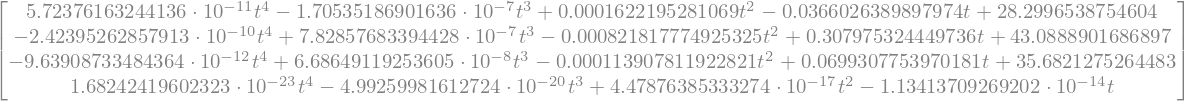

In [42]:
# Coerce results into desired format for printing
t = symbols('t')
wExpr = Matrix(np.zeros(n))
for i in range(n):
    for deg in range(k+1):
        #print(res[i,deg]*t**deg)
        wExpr[i] = wExpr[i] + res[i,deg]*t**deg

wExpr

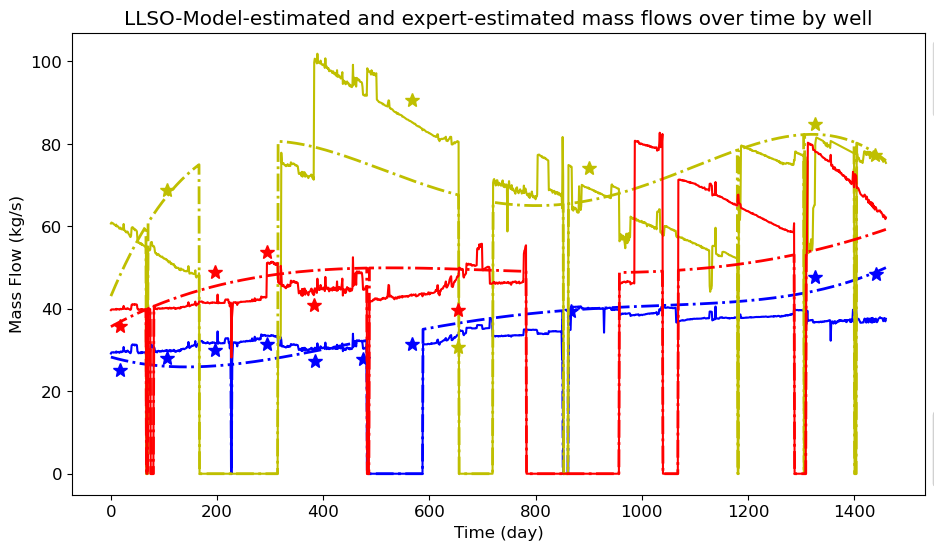

In [43]:
# Plot results from all wells
plt.figure(figsize=(11,6))
colours=['b', 'y', 'r', 'g', 'k', 'm']
lines=[]
for i in range(n-1):
    l1, = plt.plot(range(T),mEstimates[i,:][:], colours[i]+'-', lw=1.5, label="Expert-Estimated flow for well "+str(i))
    # Plot Time-Dependently
    toplot = []
    for time in range(T):
        resplot = wExpr[i].subs(t, time)
        toplot.append(resplot*zReal[i,time])
        #print(time, toplot)
    l2, = plt.plot(range(T),toplot, colours[i]+'-.', lw=2, label="Model-Estimated flow for well "+str(i))
    # Plot TFT points
    monthplot = []
    tftplot = []
    for month,element in enumerate(tftReal[i,:]):
        if element != 0:
            monthplot.append(month)
            tftplot.append(tftReal[i,month])
    l3, = plt.plot(monthplot, tftplot, colours[i]+'*', markersize=10, label="TFT measurements for well "+str(i))
    lines.append([l1,l2,l3])  
    
plt.title("LLSO-Model-estimated and expert-estimated mass flows over time by well")
plt.xlabel("Time (day)")
plt.ylabel("Mass Flow (kg/s)")
#plt.legend(bbox_to_anchor=(0.9, 1.05))

legend1 = plt.legend(lines[0], ["Expert's Estimate", "LLSO Model Estimate", "TFT Point Provided"], bbox_to_anchor=(1., 1.0), loc='upper left')
legend2 = plt.legend([l[0] for l in lines], ["Well 1", "Well 2", "Well 3", "Well 4", "Well 5"], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.gca().add_artist(legend1)
plt.gca().add_artist(legend2)
plt.rcParams['font.size'] = 15

plt.savefig("RealDataLLSO.svg", bbox_inches='tight', pad_inches=4)


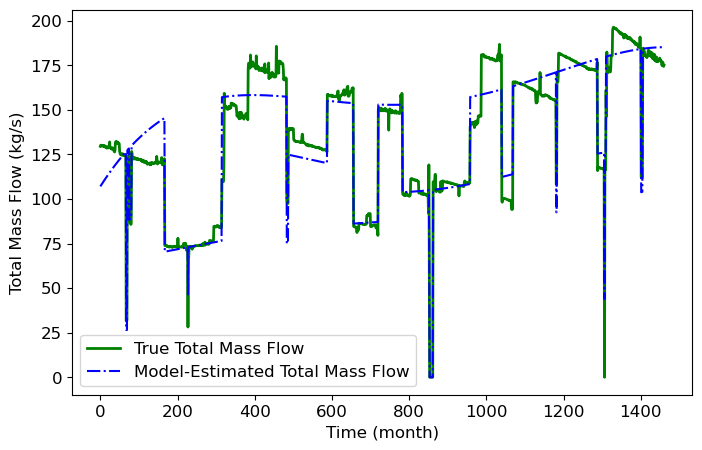

In [44]:
# # Plot total flow vs found total flow
# totalFlowFound = np.zeros((T,1))
# times = range(T)
# for time in range(T):
#     tff = [wExpr[i].subs(t, time)*zReal[i,time] for i in range(n)]
#     #print(t, tff)
#     totalFlowFound[time] = sum(tff)

# plt.plot(list(Matrix(times).T), list(MReal[0]), 'g-', lw=2, label="Expert-Estimated Total Mass Flow")
# plt.plot(times,totalFlowFound, 'b-.', lw=1.5, label="Model-Estimated Total Mass Flow")

# plt.title("LLSO-Model-estimated and expert-estimated total mass flows over time")
# plt.xlabel("Time (day)")
# plt.ylabel("Total Mass Flow (kg/s)")
# plt.legend()

# plt.savefig("Figs/FailB.svg")

plt.figure(figsize=(8,5))
plt.rcParams['font.size'] = 12
totalFlowFound = np.zeros((T,1))
times = range(T)
for t2 in range(T):
    tff = [wExpr[i].subs(t, t2)*zReal[i,t2] for i in range(n)]
    #print(t2, tff)
    totalFlowFound[t2] = sum(tff)

plt.plot(list(Matrix(times).T), list(MReal[0]), 'g-', lw=2, label="True Total Mass Flow")
plt.plot(times,totalFlowFound, 'b-.', lw=1.5, label="Model-Estimated Total Mass Flow")


#plt.title("Estimated and real total mass flows over time")
plt.xlabel("Time (month)")
plt.ylabel("Total Mass Flow (kg/s)")
plt.legend()
plt.savefig("RealB.svg", bbox_inches='tight')